# Local HybridQA workflow
CPU-only data inspection, preprocessing, sanity checks, analysis, and loading downloaded policy weights. Full neural training is intentionally absent.

In [1]:
from pathlib import Path
import json

from data_pipeline import audit_dataset, load_config, preprocess_hybridqa, load_jsonl

config = load_config('config.yaml')
config['paths']

{'hybridqa_root': 'D:\\CS_769_Project\\data\\raw\\HybridQA',
 'wikitables_root': 'D:\\CS_769_Project\\data\\raw\\WikiTables-WithLinks',
 'processed_dir': 'D:\\CS_769_Project\\data\\processed',
 'output_dir': 'D:\\CS_769_Project\\outputs'}

## 1. Audit official data

In [2]:
RUN_FULL_AUDIT = False  # enable after both official repositories are present
if RUN_FULL_AUDIT:
    audit = audit_dataset(config, inspect_tables=True)
    print(json.dumps(audit, indent=2)[:5000])

## 2. Preprocess
Start with a small subset. Set `PREPROCESS_LIMIT=None` only after inspection succeeds.

In [3]:
RUN_PREPROCESSING = False
PREPROCESS_LIMIT = 100
if RUN_PREPROCESSING:
    manifest = preprocess_hybridqa(config, max_examples=PREPROCESS_LIMIT)
    print(json.dumps(manifest, indent=2))

## 3. CPU sanity checks
These checks do not train on HybridQA.

In [4]:
RUN_SANITY_CHECKS = False
if RUN_SANITY_CHECKS:
    from training import sanity_check_training_math
    sanity_check_training_math()
    print('Sanity checks passed.')

## 4. Analyze downloaded predictions

In [5]:
from evaluation import aggregate_result_directory
result_dir = Path(config['paths']['output_dir']) / 'results'
prediction_files = sorted(result_dir.glob('*.jsonl')) if result_dir.exists() else []
if prediction_files:
    all_scores = aggregate_result_directory(result_dir)
    print(json.dumps(all_scores['summary'], indent=2))
else:
    print('No downloaded Colab predictions yet.')

{
  "direct": {
    "answer_em_mean": 0.033179457587997695,
    "answer_em_std": 0.0,
    "answer_f1_mean": 0.08261780632957336,
    "answer_f1_std": 0.0,
    "average_evidence_count_mean": 49.19763416041546,
    "average_evidence_count_std": 0.0,
    "average_latency_ms_mean": 72.69374351211773,
    "average_latency_ms_std": 0.0,
    "complete_chain_recall_mean": NaN,
    "complete_chain_recall_std": 0.0,
    "count_mean": 3466.0,
    "count_std": 0.0,
    "evidence_f1_mean": NaN,
    "evidence_f1_std": 0.0,
    "evidence_precision_mean": NaN,
    "evidence_precision_std": 0.0,
    "evidence_recall_mean": NaN,
    "evidence_recall_std": 0.0
  },
  "ppo_answer_only": {
    "answer_em_mean": 0.1745527986151183,
    "answer_em_std": 0.008999696457289213,
    "answer_f1_mean": 0.23166403548036218,
    "answer_f1_std": 0.012392930943577391,
    "average_evidence_count_mean": 2.253702635122139,
    "average_evidence_count_std": 0.2156965944251082,
    "average_latency_ms_mean": 57.012898381

D:\CS_769_Project\evaluation.py:327: RuntimeWarning: Mean of empty slice
  method_summary[f"{name}_mean"] = float(np.nanmean(values))


## 5. Run downloaded model
Loads final selector weights on CPU. It never starts supervised or PPO training.

In [6]:
RUN_DOWNLOADED_MODEL = False
if RUN_DOWNLOADED_MODEL:
    import yaml
    from models import build_actor_critic, load_policy_weights
    from training import verify_inference_bundle

    bundle = Path(config['paths']['output_dir']) / 'final_bundle'
    verify_inference_bundle(bundle)
    with (bundle / 'policy_config.yaml').open(encoding='utf-8') as handle:
        policy_config = yaml.safe_load(handle)
    policy = build_actor_critic(policy_config)
    load_policy_weights(policy, bundle / 'policy_state.pt', device='cpu')
    print('Final policy loaded on CPU. Use evaluation.policy_select(...) for an example.')

## 6. Final evaluation setup and artifact verification
The remaining cells are CPU-only. They verify the downloaded artifacts, build final tables, run paired bootstrap tests, create plots, and select the final checkpoint.

In [7]:
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

output_dir = Path(config['paths']['output_dir'])
result_dir = output_dir / 'results'
runs_dir = output_dir / 'colab_runs'
analysis_dir = output_dir / 'analysis'
analysis_dir.mkdir(parents=True, exist_ok=True)
variants = ['evidence_only', 'answer_only', 'combined', 'combined_step']
seeds = list(config['training']['seeds'])

expected_prediction_stems = (
    ['direct', 'similarity']
    + [f'supervised_seed_{seed}' for seed in seeds]
    + [f'ppo_{variant}_seed_{seed}' for variant in variants for seed in seeds]
)
expected_checkpoints = [
    runs_dir / f'ppo_{variant}_seed_{seed}' / checkpoint
    for variant in variants
    for seed in seeds
    for checkpoint in ('latest.pt', 'best.pt')
]
missing_predictions = [result_dir / f'{stem}.jsonl' for stem in expected_prediction_stems if not (result_dir / f'{stem}.jsonl').exists()]
missing_checkpoints = [path for path in expected_checkpoints if not path.exists()]
if missing_predictions or missing_checkpoints:
    raise FileNotFoundError('Missing artifacts:\n' + '\n'.join(map(str, missing_predictions + missing_checkpoints)))

verification = pd.DataFrame([
    {'artifact': 'Prediction JSONL files', 'expected': 17, 'found': len(list(result_dir.glob('*.jsonl')))},
    {'artifact': 'PPO run directories', 'expected': 12, 'found': len(list(runs_dir.glob('ppo_*_seed_*')))},
    {'artifact': 'PPO best checkpoints', 'expected': 12, 'found': len(list(runs_dir.glob('ppo_*_seed_*/best.pt')))},
    {'artifact': 'PPO latest checkpoints', 'expected': 12, 'found': len(list(runs_dir.glob('ppo_*_seed_*/latest.pt')))},
    {'artifact': 'Supervised best models', 'expected': 3, 'found': len(list(runs_dir.glob('supervised_seed_*/best_model.pt')))},
])
verification['status'] = np.where(verification['expected'] == verification['found'], 'OK', 'CHECK')
display(verification)
print(f'Analysis output directory: {analysis_dir}')
print('All required evaluation and checkpoint artifacts are present.')

,artifact,expected,found,status
0,Prediction JSONL files,17,17,OK
1,PPO run directories,12,12,OK
2,PPO best checkpoints,12,12,OK
3,PPO latest checkpoints,12,12,OK
4,Supervised best models,3,3,OK


Analysis output directory: D:\CS_769_Project\outputs\analysis
All required evaluation and checkpoint artifacts are present.


## 7. Method-level comparison
Trained-method values are means across three seeds. Baselines have one run.

In [8]:
from evaluation import aggregate_result_directory

with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=RuntimeWarning)
    all_scores = aggregate_result_directory(result_dir)

method_labels = {
    'direct': 'Direct QA',
    'similarity': 'Similarity',
    'supervised': 'Supervised',
    'ppo_evidence_only': 'PPO evidence-only',
    'ppo_answer_only': 'PPO answer-only',
    'ppo_combined': 'PPO combined',
    'ppo_combined_step': 'PPO combined + step cost',
}
summary_rows = []
for method, metrics in all_scores['summary'].items():
    summary_rows.append({
        'method_key': method,
        'Method': method_labels.get(method, method),
        'Runs': len([name for name in all_scores['per_run'] if re.sub(r'_seed_\d+$', '', name) == method]),
        'Answer EM': metrics['answer_em_mean'],
        'Answer EM std': metrics['answer_em_std'],
        'Answer F1': metrics['answer_f1_mean'],
        'Answer F1 std': metrics['answer_f1_std'],
        'Evidence F1': metrics['evidence_f1_mean'],
        'Evidence F1 std': metrics['evidence_f1_std'],
        'Evidence precision': metrics['evidence_precision_mean'],
        'Evidence recall': metrics['evidence_recall_mean'],
        'Complete-chain recall': metrics['complete_chain_recall_mean'],
        'Avg evidence count': metrics['average_evidence_count_mean'],
        'Latency (ms)': metrics['average_latency_ms_mean'],
    })
method_table = pd.DataFrame(summary_rows).sort_values('Answer F1', ascending=False).reset_index(drop=True)
method_table.to_csv(analysis_dir / 'method_comparison.csv', index=False)
display(method_table.drop(columns=['method_key']).style.format(precision=4).highlight_max(subset=['Answer EM', 'Answer F1', 'Evidence F1'], color='#d9ead3'))

,Method,Runs,Answer EM,Answer EM std,Answer F1,Answer F1 std,Evidence F1,Evidence F1 std,Evidence precision,Evidence recall,Complete-chain recall,Avg evidence count,Latency (ms)
0,PPO answer-only,3,0.1746,0.0090,0.2317,0.0124,0.3250,0.0057,0.3001,0.3770,0.3408,2.2537,57.0129
1,PPO combined,3,0.1716,0.0072,0.2271,0.0092,0.3495,0.0055,0.3437,0.3726,0.3286,1.8947,56.4931
2,PPO combined + step cost,3,0.1677,0.0059,0.2243,0.0060,0.3541,0.0100,0.3612,0.3625,0.3083,1.7068,55.9721
3,PPO evidence-only,3,0.1679,0.0057,0.2214,0.0059,0.3529,0.0043,0.3639,0.3576,0.3017,1.6560,56.4676
4,Supervised,3,0.1607,0.0043,0.2145,0.0050,0.3685,0.0013,0.3995,0.3575,0.2850,1.4656,55.6533
5,Similarity,1,0.0635,0.0000,0.1131,0.0000,0.2616,0.0000,0.2046,0.3872,0.1921,3.0000,59.0907
6,Direct QA,1,0.0332,0.0000,0.0826,0.0000,nan,0.0000,nan,nan,nan,49.1976,72.6937


## 8. Individual-run ranking
This identifies the strongest concrete checkpoint after comparing methods across seeds.

In [9]:
run_rows = []
for run_name, metrics in all_scores['per_run'].items():
    run_rows.append({
        'Run': run_name,
        'Answer EM': metrics['answer_em'],
        'Answer F1': metrics['answer_f1'],
        'Evidence F1': metrics['evidence_f1'],
        'Evidence count': metrics['average_evidence_count'],
        'Latency (ms)': metrics['average_latency_ms'],
    })
per_run_table = pd.DataFrame(run_rows).sort_values('Answer F1', ascending=False).reset_index(drop=True)
per_run_table.to_csv(analysis_dir / 'per_run_ranking.csv', index=False)
display(per_run_table.style.format(precision=4).highlight_max(subset=['Answer EM', 'Answer F1', 'Evidence F1'], color='#d9ead3'))

,Run,Answer EM,Answer F1,Evidence F1,Evidence count,Latency (ms)
0,ppo_answer_only_seed_42,0.1841,0.2452,0.3272,2.4339,57.0510
1,ppo_combined_seed_2026,0.1786,0.2365,0.3436,2.0880,56.7531
2,ppo_combined_step_seed_42,0.1740,0.2308,0.3641,1.7072,55.7254
3,ppo_answer_only_seed_2026,0.1734,0.2288,0.3185,2.3125,57.4120
4,ppo_evidence_only_seed_42,0.1746,0.2276,0.3538,1.6795,56.4510
5,ppo_combined_seed_13,0.1720,0.2266,0.3502,1.9106,56.5650
6,ppo_combined_step_seed_13,0.1671,0.2231,0.3542,1.6549,55.9632
7,ppo_answer_only_seed_13,0.1662,0.2210,0.3292,2.0147,56.5757
8,ppo_evidence_only_seed_13,0.1647,0.2208,0.3483,1.7285,56.4429
9,ppo_combined_step_seed_2026,0.1621,0.2190,0.3440,1.7582,56.2278


## 9. Paired bootstrap significance tests
Per-question scores are averaged across the three seeds for each method, then paired over the same evaluation questions. A 95% bootstrap interval excluding zero is marked significant.

In [10]:
from evaluation import answer_exact_match, answer_f1, evidence_metrics, paired_bootstrap_difference

def per_question_scores(path):
    records = {}
    for row in load_jsonl(path):
        evidence = evidence_metrics(row.get('selected_ids', []), row.get('gold_sets', []))
        records[str(row['question_id'])] = {
            'answer_em': answer_exact_match(str(row['prediction']), str(row['answer'])),
            'answer_f1': answer_f1(str(row['prediction']), str(row['answer'])),
            'evidence_f1': evidence['f1'],
        }
    return records

def finite_mean(values):
    values = np.asarray(values, dtype='float64')
    finite = values[np.isfinite(values)]
    return float(np.mean(finite)) if len(finite) else np.nan

trained_methods = ['supervised'] + [f'ppo_{variant}' for variant in variants]
method_question_scores = {}
for method in trained_methods:
    seed_scores = [per_question_scores(result_dir / f'{method}_seed_{seed}.jsonl') for seed in seeds]
    question_ids = sorted(set.intersection(*(set(scores) for scores in seed_scores)))
    method_question_scores[method] = {
        metric: np.asarray([finite_mean([scores[qid][metric] for scores in seed_scores]) for qid in question_ids])
        for metric in ('answer_em', 'answer_f1', 'evidence_f1')
    }

bootstrap_rows = []
for method in [f'ppo_{variant}' for variant in variants]:
    for metric in ('answer_em', 'answer_f1', 'evidence_f1'):
        first = method_question_scores[method][metric]
        second = method_question_scores['supervised'][metric]
        finite_pairs = np.isfinite(first) & np.isfinite(second)
        result = paired_bootstrap_difference(
            first[finite_pairs],
            second[finite_pairs],
            samples=10_000,
            seed=42,
        )
        bootstrap_rows.append({
            'Comparison': f"{method_labels[method]} - Supervised",
            'Metric': metric.replace('_', ' ').title(),
            'Paired N': int(finite_pairs.sum()),
            'Difference': result['difference'],
            '95% CI low': result['ci_low'],
            '95% CI high': result['ci_high'],
            'Significant': (result['ci_low'] > 0) or (result['ci_high'] < 0),
        })
bootstrap_table = pd.DataFrame(bootstrap_rows)
bootstrap_table.to_csv(analysis_dir / 'paired_bootstrap.csv', index=False)
print(f'Paired questions per method: {len(question_ids):,}; bootstrap samples per comparison: 10,000')
display(bootstrap_table.style.format({'Difference': '{:+.4f}', '95% CI low': '{:+.4f}', '95% CI high': '{:+.4f}'}))

Paired questions per method: 3,466; bootstrap samples per comparison: 10,000


,Comparison,Metric,Paired N,Difference,95% CI low,95% CI high,Significant
0,PPO evidence-only - Supervised,Answer Em,3466,+0.0072,+0.0016,+0.0131,True
1,PPO evidence-only - Supervised,Answer F1,3466,+0.0069,+0.0011,+0.0128,True
2,PPO evidence-only - Supervised,Evidence F1,3374,-0.0156,-0.0214,-0.0098,True
3,PPO answer-only - Supervised,Answer Em,3466,+0.0138,+0.0063,+0.0214,True
4,PPO answer-only - Supervised,Answer F1,3466,+0.0172,+0.0096,+0.0248,True
5,PPO answer-only - Supervised,Evidence F1,3374,-0.0436,-0.0506,-0.0362,True
6,PPO combined - Supervised,Answer Em,3466,+0.0109,+0.0041,+0.0177,True
7,PPO combined - Supervised,Answer F1,3466,+0.0126,+0.0058,+0.0196,True
8,PPO combined - Supervised,Evidence F1,3374,-0.0190,-0.0255,-0.0126,True
9,PPO combined + step cost - Supervised,Answer Em,3466,+0.0070,+0.0012,+0.0130,True


## 10. Final comparison plots

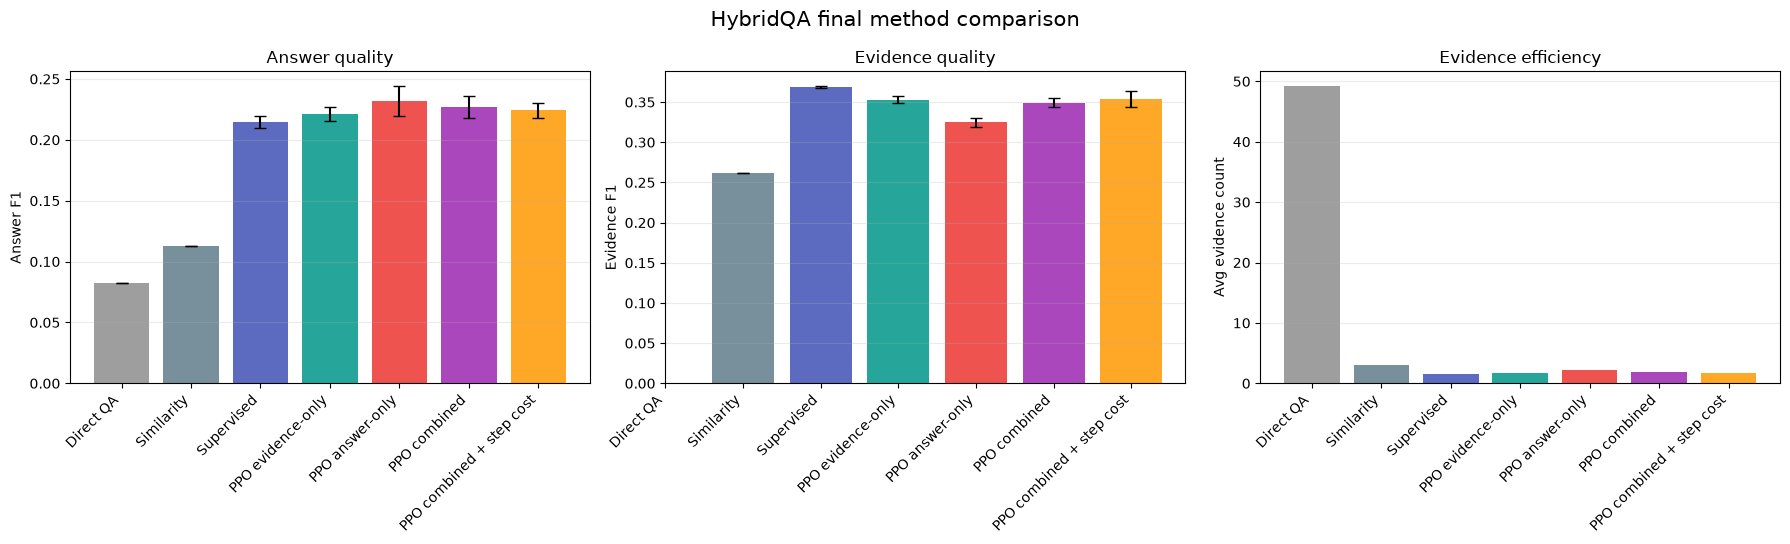

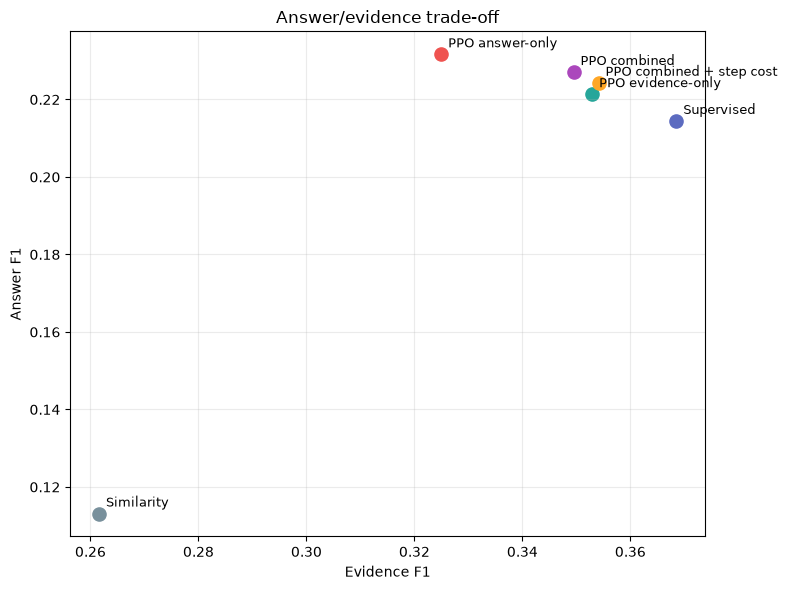

In [11]:
plot_table = method_table.set_index('Method').loc[[
    'Direct QA', 'Similarity', 'Supervised', 'PPO evidence-only',
    'PPO answer-only', 'PPO combined', 'PPO combined + step cost'
]]
colors = ['#9e9e9e', '#78909c', '#5c6bc0', '#26a69a', '#ef5350', '#ab47bc', '#ffa726']
figure, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for axis, metric, std_metric, title in [
    (axes[0], 'Answer F1', 'Answer F1 std', 'Answer quality'),
    (axes[1], 'Evidence F1', 'Evidence F1 std', 'Evidence quality'),
    (axes[2], 'Avg evidence count', None, 'Evidence efficiency'),
]:
    values = plot_table[metric].to_numpy()
    errors = plot_table[std_metric].fillna(0).to_numpy() if std_metric else None
    axis.bar(range(len(plot_table)), values, yerr=errors, capsize=4, color=colors)
    axis.set_title(title)
    axis.set_ylabel(metric)
    axis.set_xticks(range(len(plot_table)), plot_table.index, rotation=45, ha='right')
    axis.grid(axis='y', alpha=0.25)
figure.suptitle('HybridQA final method comparison', fontsize=15)
figure.tight_layout()
figure.savefig(analysis_dir / 'method_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

figure, axis = plt.subplots(figsize=(8, 6))
for color, (name, row) in zip(colors, plot_table.iterrows()):
    if np.isfinite(row['Evidence F1']):
        axis.scatter(row['Evidence F1'], row['Answer F1'], s=90, color=color)
        axis.annotate(name, (row['Evidence F1'], row['Answer F1']), xytext=(5, 5), textcoords='offset points', fontsize=9)
axis.set_xlabel('Evidence F1')
axis.set_ylabel('Answer F1')
axis.set_title('Answer/evidence trade-off')
axis.grid(alpha=0.25)
figure.tight_layout()
figure.savefig(analysis_dir / 'answer_evidence_tradeoff.png', dpi=180, bbox_inches='tight')
plt.show()

## 11. Final checkpoint selection and training diagnostics
The PPO variant is selected by mean answer F1 across seeds; its concrete checkpoint is selected by the highest individual answer F1.

,selection_metric,selected_method,selected_run,selected_seed,checkpoint,answer_em,answer_f1,evidence_f1,average_evidence_count
0,answer_f1,ppo_answer_only,ppo_answer_only_seed_42,42,D:\CS_769_Project\outputs\colab_runs\ppo_answe...,0.184074,0.245249,0.327159,2.43393


Selected checkpoint exists: True


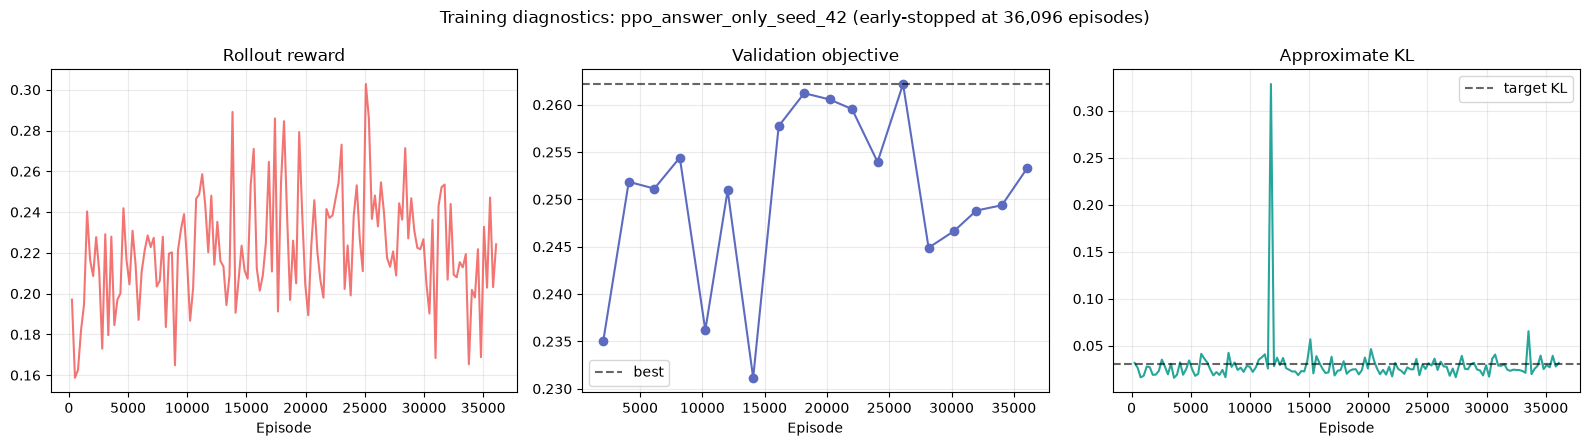

In [12]:
ppo_method_rows = method_table[method_table['method_key'].str.startswith('ppo_')]
selected_method = ppo_method_rows.sort_values('Answer F1', ascending=False).iloc[0]['method_key']
selected_runs = per_run_table[per_run_table['Run'].str.startswith(selected_method + '_seed_')]
selected_run = selected_runs.sort_values('Answer F1', ascending=False).iloc[0]
selected_seed = int(re.search(r'_seed_(\d+)$', selected_run['Run']).group(1))
selected_checkpoint = runs_dir / selected_run['Run'] / 'best.pt'
selection = {
    'selection_metric': 'answer_f1',
    'selected_method': selected_method,
    'selected_run': selected_run['Run'],
    'selected_seed': selected_seed,
    'checkpoint': str(selected_checkpoint.resolve()),
    'answer_em': float(selected_run['Answer EM']),
    'answer_f1': float(selected_run['Answer F1']),
    'evidence_f1': float(selected_run['Evidence F1']),
    'average_evidence_count': float(selected_run['Evidence count']),
}
(analysis_dir / 'final_selection.json').write_text(json.dumps(selection, indent=2), encoding='utf-8')
display(pd.DataFrame([selection]))
print(f"Selected checkpoint exists: {selected_checkpoint.exists()}")

import torch
checkpoint = torch.load(runs_dir / selected_run['Run'] / 'latest.pt', map_location='cpu', weights_only=False)
progress = checkpoint['progress']
training_log = pd.DataFrame(progress['logs'])
figure, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(training_log['episode'], training_log['reward'], color='#ef5350', alpha=0.8)
axes[0].set_title('Rollout reward')
validation_log = training_log.dropna(subset=['validation'])
axes[1].plot(validation_log['episode'], validation_log['validation'], marker='o', color='#5c6bc0')
axes[1].axhline(progress['best_validation'], linestyle='--', color='black', alpha=0.6, label='best')
axes[1].legend()
axes[1].set_title('Validation objective')
axes[2].plot(training_log['episode'], training_log['approximate_kl'], color='#26a69a')
axes[2].axhline(config['training']['target_kl'], linestyle='--', color='black', alpha=0.6, label='target KL')
axes[2].legend()
axes[2].set_title('Approximate KL')
for axis in axes:
    axis.set_xlabel('Episode')
    axis.grid(alpha=0.25)
figure.suptitle(f"Training diagnostics: {selected_run['Run']} (early-stopped at {progress['episode']:,} episodes)")
figure.tight_layout()
figure.savefig(analysis_dir / 'selected_training_diagnostics.png', dpi=180, bbox_inches='tight')
plt.show()

## 12. Analysis deliverables
All tables, plots, and the machine-readable final selection are saved under `outputs/analysis`.

In [13]:
deliverables = sorted(path for path in analysis_dir.iterdir() if path.is_file())
display(pd.DataFrame({
    'File': [path.name for path in deliverables],
    'Size (KiB)': [round(path.stat().st_size / 1024, 1) for path in deliverables],
}))
print(f'Created {len(deliverables)} final-analysis files.')

,File,Size (KiB)
0,answer_evidence_tradeoff.png,55.0
1,final_selection.json,0.4
2,method_comparison.csv,1.7
3,method_comparison.png,152.1
4,paired_bootstrap.csv,1.4
5,per_run_ranking.csv,2.0
6,selected_training_diagnostics.png,226.3


Created 7 final-analysis files.
